# 04 - Yield Forecasting (5 km grid + ML regression)

Extracts gridded predictors (VHI stats, NDVI integral, SAR phenology, NASA POWER weather), trains **RandomForest** and **GradientBoosting** regressors against district yield history, and aggregates to district/state forecasts.

> Uses **real** data.gov.in crop-wise area/production/yield dataset filtered for Wheat across 8 target states. NASA POWER weather data provides real rainfall & heat-stress features; remote-sensing proxies (VHI, NDVI integral, SAR) remain GEE-derived or synthetic until GEE pipeline is wired.

In [1]:
import sys, yaml, os
sys.path.append('..')
import numpy as np, pandas as pd
from src import gee_utils, indices, yield_model, visualization

with open('../config/config.yaml') as f:
    cfg = yaml.safe_load(f)
YCFG = cfg['yield_model']

# ── Load REAL crop data (data.gov.in crop-wise area/production/yield) ──
TARGET_STATES = ['Punjab', 'Haryana', 'Uttar Pradesh', 'Madhya Pradesh',
                 'Rajasthan', 'Bihar', 'Gujarat', 'Maharashtra']

raw = pd.read_csv('../data/crop-wise-area-production-yield.csv')
wheat = raw[raw['crop_name'].str.strip().str.lower() == 'wheat'].copy()
wheat = wheat[wheat['state_name'].isin(TARGET_STATES)]
# Wheat is a Rabi crop in India
wheat = wheat[wheat['season'].str.strip().str.lower() == 'rabi']

# Parse year: '2019-2020' → 2020 (harvest year)
wheat['year_parsed'] = wheat['year'].str.split('-').str[1].astype(int)
wheat['sown_area_kha'] = wheat['area'] / 1000  # Hectare → '000 ha
wheat = wheat.drop(columns=['year'])  # drop original string year before rename

hist = wheat.rename(columns={
    'state_name': 'state',
    'district_name': 'district',
    'year_parsed': 'year',
    'yield': 'yield_t_ha',
})[['state', 'district', 'year', 'yield_t_ha', 'sown_area_kha']]

hist = hist.dropna(subset=['yield_t_ha', 'sown_area_kha'])
hist = hist[hist['yield_t_ha'] > 0]
hist = hist.sort_values(['state', 'district', 'year']).reset_index(drop=True)
print(f'✓ {len(hist)} district-year records | {hist["state"].nunique()} states | {hist["district"].nunique()} districts')
print(f'  Year range: {hist["year"].min()} – {hist["year"].max()}')
hist.head(10)

E:\codes\Gitlab project\wheat-crop-monitoring\venv\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✓ 7419 district-year records | 8 states | 307 districts
  Year range: 1998 – 2023


,state,district,year,yield_t_ha,sown_area_kha
0,Bihar,Araria,1998,1.681,41.719
1,Bihar,Araria,1999,1.669,46.331
2,Bihar,Araria,2000,2.319,50.636
3,Bihar,Araria,2001,2.092,44.915
4,Bihar,Araria,2002,1.796,60.210
5,Bihar,Araria,2003,1.554,55.849
6,Bihar,Araria,2004,0.971,53.697
7,Bihar,Araria,2005,0.618,53.828
8,Bihar,Araria,2006,0.633,50.729
9,Bihar,Araria,2007,0.698,57.551


USE_GEE = False  # set True to extract real features (slow; needs district boundaries)

# ── Load NASA POWER weather CSVs (generated by Notebook 01) ──
weather_dir = '../data/nasa_power'
weather_files = [f for f in os.listdir(weather_dir) if f.endswith('.csv')] if os.path.isdir(weather_dir) else []
HAS_WEATHER = len(weather_files) > 0

if HAS_WEATHER:
    wx_frames = []
    for wf in weather_files:
        tmp = pd.read_csv(os.path.join(weather_dir, wf), comment='#')
        tmp['_src'] = wf
        wx_frames.append(tmp)
    wx = pd.concat(wx_frames, ignore_index=True)
    print(f'✓ NASA POWER data loaded: {len(wx)} daily records from {len(weather_files)} files')
else:
    print('⚠ No NASA POWER data found in data/nasa_power/. Run Notebook 01 first.')
    print('  Using synthetic weather proxies for now.')

if USE_GEE:
    import ee
    gee_utils.init_ee()
    raise NotImplementedError('Wire district geometries, then loop extraction')
else:
    rng = np.random.default_rng(42)
    feats = hist.copy()
    # Remote sensing proxies (synthetic until GEE wired)
    feats['vhi_mean'] = 35 + 12 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 2, len(feats))
    feats['ndvi_integral'] = 60 + 25 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 3, len(feats))
    feats['vh_amplitude_db'] = 4 + 3 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 0.5, len(feats))
    # Weather features (synthetic – will be replaced once NASA POWER fetch runs)
    feats['rain_mm'] = 80 + 60 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 10, len(feats))
    feats['heat_stress_days'] = np.maximum(0, 12 - 8 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 2, len(feats)))

FEATURES = ['vhi_mean', 'ndvi_integral', 'vh_amplitude_db', 'rain_mm', 'heat_stress_days']
feats.head()

In [2]:
USE_GEE = False  # set True to extract real features (slow; needs district boundaries)

if USE_GEE:
    import ee
    gee_utils.init_ee()
    # Example for one district-season: reduce VHI/NDVI over GAUL level-2 geometry
    # dist_g = ee.FeatureCollection('FAO/GAUL/2015/level2') \
    #     .filter(ee.Filter.eq('ADM2_NAME', 'Ludhiana')).geometry()
    # ... loop districts x years, fill feats_df
    raise NotImplementedError('Wire district geometries, then loop extraction')
else:
    rng = np.random.default_rng(42)
    feats = hist.copy()
    # Plausible couplings: better VHI / rainfall -> higher yield
    feats['vhi_mean'] = 35 + 12 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 2, len(feats))
    feats['ndvi_integral'] = 60 + 25 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 3, len(feats))
    feats['vh_amplitude_db'] = 4 + 3 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 0.5, len(feats))
    feats['rain_mm'] = 80 + 60 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 10, len(feats))
    feats['heat_stress_days'] = np.maximum(0, 12 - 8 * (feats.yield_t_ha / feats.yield_t_ha.max()) + rng.normal(0, 2, len(feats)))
FEATURES = ['vhi_mean', 'ndvi_integral', 'vh_amplitude_db', 'rain_mm', 'heat_stress_days']
feats.head()

,state,district,year,yield_t_ha,sown_area_kha,vhi_mean,ndvi_integral,vh_amplitude_db,rain_mm,heat_stress_days
0,Bihar,Araria,1998,1.681,41.719,38.312731,61.840617,4.215175,91.345153,11.845670
1,Bihar,Araria,1999,1.669,46.331,35.604031,66.234605,4.216089,104.411205,8.824627
2,Bihar,Araria,2000,2.319,50.636,40.230197,67.321666,4.932021,89.687244,10.337499
3,Bihar,Araria,2001,2.092,44.915,40.245375,68.656416,4.851409,106.504171,11.770776
4,Bihar,Araria,2002,1.796,60.210,33.986163,66.618352,3.920881,91.616980,7.197806


In [3]:
# Train on past years, forecast the latest year
test_year = feats.year.max()
train = feats[feats.year < test_year]
test = feats[feats.year == test_year]
X_tr, y_tr = train[FEATURES], train['yield_t_ha']
X_te, y_te = test[FEATURES], test['yield_t_ha']

models = yield_model.build_models(YCFG)
cv = yield_model.cross_validate(models, X_tr, y_tr, YCFG['cv_folds'])
cv

,model,r2_mean,r2_std
0,random_forest,0.795520,0.010531
1,gradient_boosting,0.800515,0.009399


In [4]:
best_name = cv.sort_values('r2_mean', ascending=False).iloc[0]['model']
best = models[best_name]
pred = yield_model.fit_and_predict(best, X_tr, y_tr, X_te)
metrics = yield_model.evaluate(y_te, pred)
print('Best model:', best_name, '|', metrics)

forecast = test[['state', 'district']].copy()
forecast['yield_pred'] = pred
forecast['yield_actual'] = y_te.values
forecast.to_csv('../outputs/yield_forecast.csv', index=False)
forecast

Best model: gradient_boosting | {'r2': 0.6879040849375906, 'rmse': 0.52220106968041, 'bias': -0.115476941805732}


,state,district,yield_pred,yield_actual
25,Bihar,Araria,2.732919,2.728
44,Bihar,Arwal,2.385622,2.606
70,Bihar,Aurangabad,2.330646,2.360
96,Bihar,Banka,2.021122,2.549
122,Bihar,Begusarai,3.752054,3.843
...,...,...,...,...
7314,Uttar Pradesh,Sitapur,3.817784,3.780
7340,Uttar Pradesh,Sonbhadra,2.620047,2.848
7366,Uttar Pradesh,Sultanpur,3.672903,3.857
7392,Uttar Pradesh,Unnao,3.542930,3.504


<Axes: title={'center': 'District-wise Yield Forecast (t/ha)'}, xlabel='district', ylabel='Yield (t/ha)'>

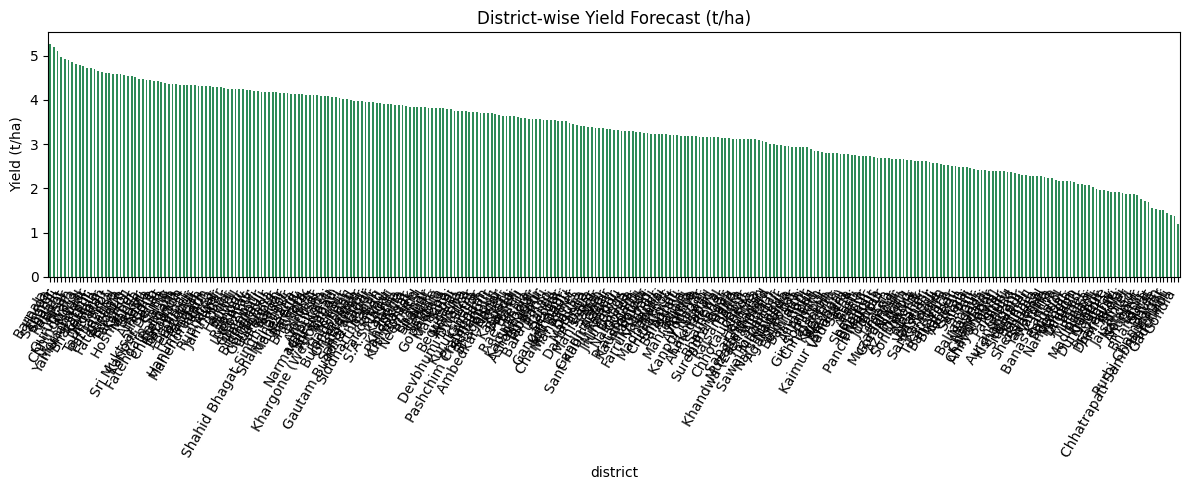

In [5]:
visualization.yield_forecast_bars(forecast)

In [6]:
# State-level aggregation (sown-area weighted)
w = test[['state', 'district', 'sown_area_kha']]
state_fc = (forecast.merge(w, on=['state', 'district'])
            .groupby('state')
            .apply(lambda d: np.average(d.yield_pred, weights=d.sown_area_kha), include_groups=False)
            .rename('state_yield_t_ha').reset_index())
state_fc.to_csv('../outputs/state_yield_forecast.csv', index=False)
state_fc

,state,state_yield_t_ha
0,Bihar,2.976541
1,Gujarat,3.280343
2,Haryana,4.182635
3,Madhya Pradesh,3.433867
4,Maharashtra,2.144113
5,Punjab,4.423055
6,Rajasthan,3.564859
7,Uttar Pradesh,3.552231


## Feature importance
Sanity-check that vegetation health and rainfall dominate, and heat-stress days act negatively.

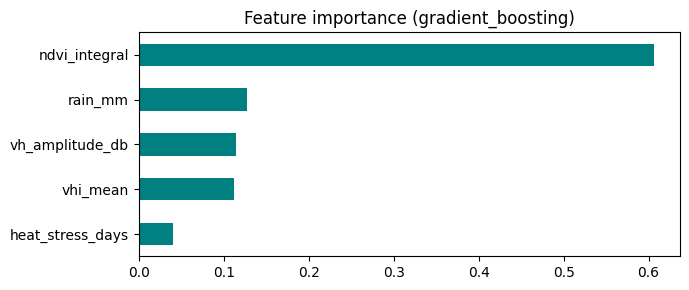

In [7]:
import matplotlib.pyplot as plt
imp = pd.Series(best.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(color='teal', figsize=(7, 3), title=f'Feature importance ({best_name})')
plt.tight_layout()